# 1. Contexte et objectif

Ce notebook part d'un backlog produit (`BACKLOG.md`) et d'un catalogue de données (`DATA_CATALOG.md`) construits en amont, comme le ferait un Product Owner avant de lancer un développement de dashboard RH. L'idée n'est pas de produire un modèle prédictif, mais de montrer la chaîne complète : besoin métier formulé en user stories, KPIs qui en découlent, qualité de la donnée vérifiée avant de calculer quoi que ce soit, requêtage explicite, puis restitution.

Le jeu de données est le jeu public IBM HR Analytics Employee Attrition (1470 collaborateurs, 35 champs), utilisé ici comme support pour démontrer la méthode, pas comme donnée réelle d'entreprise.

Un guide utilisateur autonome pour lire le dashboard qui découle de ce notebook est disponible dans `USER_GUIDE.md`.

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/hr_employee_attrition.csv", encoding="utf-8-sig")
df.shape

(1470, 35)

# 2. Audit qualité (Epic 1 du backlog)

Avant de calculer le moindre KPI, on applique les règles de qualité listées dans `DATA_CATALOG.md` : complétude, unicité de la clé primaire, détection des champs constants. C'est la user story 1.2 du backlog, elle bloque tout le reste tant qu'elle n'est pas faite.

In [2]:
# Q5 : complétude
missing = df.isna().sum()
n_missing_fields = (missing > 0).sum()

# Q4 : unicité de la clé primaire
n_rows = len(df)
n_unique_ids = df["EmployeeNumber"].nunique()

# Q1 : champs constants
constant_fields = [c for c in df.columns if df[c].nunique() == 1]

quality_report = pd.DataFrame({
    "règle": ["Q5 complétude", "Q4 unicité clé primaire", "Q1 champs constants"],
    "résultat": [
        f"{n_missing_fields} champ(s) avec valeurs manquantes sur {df.shape[1]}",
        f"{n_unique_ids} valeurs distinctes pour {n_rows} lignes",
        f"{len(constant_fields)} champ(s) constant(s) : {constant_fields}",
    ],
})
quality_report

,règle,résultat
0,Q5 complétude,0 champ(s) avec valeurs manquantes sur 35
1,Q4 unicité clé primaire,1470 valeurs distinctes pour 1470 lignes
2,Q1 champs constants,"3 champ(s) constant(s) : ['EmployeeCount', 'Ov..."


**Comment lire ce résultat.** Les trois règles passent : aucune valeur manquante, la clé primaire `EmployeeNumber` est bien unique (utilisable pour toute jointure future), et trois champs (`EmployeeCount`, `Over18`, `StandardHours`) sont confirmés constants comme documenté dans le catalogue, donc exclus des analyses qui suivent plutôt que traités comme un signal.

In [3]:
# on écarte les champs constants pour la suite, ils n'apportent aucune information
df = df.drop(columns=constant_fields)
df["Attrition_flag"] = (df["Attrition"] == "Yes").astype(int)
df.shape

(1470, 33)

# 3. Requêtage SQL (transposable à Snowflake)

L'offre qui a motivé ce projet demande explicitement de l'écriture de requêtes sur Snowflake. Je n'ai pas d'accès Snowflake pour un projet portfolio, donc les KPIs ci-dessous sont écrits en SQL via DuckDB plutôt qu'en `pandas.groupby`, DuckDB utilise un dialecte SQL standard (fenêtrage, CTE, agrégations) qui se transpose directement en Snowflake SQL, seule la connexion change. Le reste du notebook revient à pandas pour les tests statistiques et les graphiques, DuckDB n'étant pas l'outil pour ça.

In [4]:
con = duckdb.connect()
con.register("employees", df)

attrition_by_dept = con.execute('''
    SELECT
        Department,
        COUNT(*) AS effectif,
        SUM(Attrition_flag) AS departs,
        ROUND(SUM(Attrition_flag) * 1.0 / COUNT(*), 4) AS taux_attrition
    FROM employees
    GROUP BY Department
    ORDER BY taux_attrition DESC
''').df().set_index("Department")

attrition_by_dept

,effectif,departs,taux_attrition
Department,,,
Sales,446,92.0,0.2063
Human Resources,63,12.0,0.1905
Research & Development,961,133.0,0.1384


In [5]:
attrition_by_role = con.execute('''
    SELECT
        JobRole,
        COUNT(*) AS effectif,
        SUM(Attrition_flag) AS departs,
        ROUND(SUM(Attrition_flag) * 1.0 / COUNT(*), 4) AS taux_attrition
    FROM employees
    GROUP BY JobRole
    ORDER BY taux_attrition DESC
''').df().set_index("JobRole")

attrition_by_role

,effectif,departs,taux_attrition
JobRole,,,
Sales Representative,83,33.0,0.3976
Laboratory Technician,259,62.0,0.2394
Human Resources,52,12.0,0.2308
Sales Executive,326,57.0,0.1748
Research Scientist,292,47.0,0.1610
Manufacturing Director,145,10.0,0.0690
Healthcare Representative,131,9.0,0.0687
Manager,102,5.0,0.0490
Research Director,80,2.0,0.0250


**Comment lire ce résultat.** Les deux tables ci-dessus sont produites par des requêtes SQL explicites (`GROUP BY`, agrégations), pas par du code pandas caché. C'est la même logique de requêtage qu'on écrirait sur un entrepôt Snowflake en production : `SELECT`, `GROUP BY`, agrégat conditionnel. Le reste du notebook réutilise ces deux tables pour les visualisations.

# 4. KPI attrition par département et par poste (user story 2.1)

La user story demande un taux d'attrition ventilé, avec les effectifs sous-jacents visibles, pas juste un pourcentage brut qui masquerait des petits effectifs. Les chiffres viennent des requêtes SQL de la section 3.

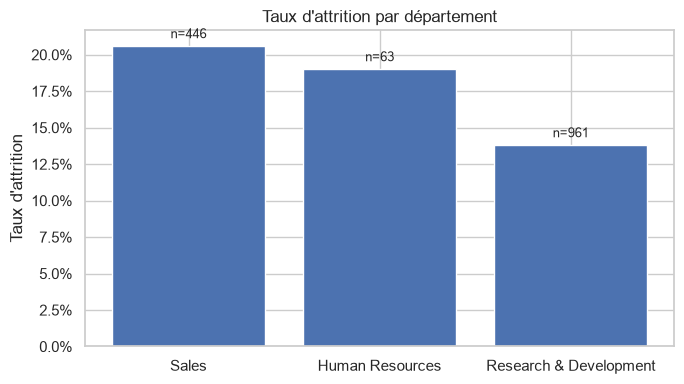

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(attrition_by_dept.index, attrition_by_dept["taux_attrition"], color="#4C72B0")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Taux d'attrition")
ax.set_title("Taux d'attrition par département")
for bar, effectif in zip(bars, attrition_by_dept["effectif"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"n={effectif}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/kpi_attrition_par_departement.png", dpi=150)
plt.show()

In [7]:
worst_dept = attrition_by_dept.index[0]
worst_rate = attrition_by_dept.loc[worst_dept, "taux_attrition"]
best_dept = attrition_by_dept.index[-1]
best_rate = attrition_by_dept.loc[best_dept, "taux_attrition"]

display(Markdown(
    f"**Comment lire ce résultat.** Le taux d'attrition va de `{best_rate:.1%}` ({best_dept}) à "
    f"`{worst_rate:.1%}` ({worst_dept}). L'effectif (`n=`) est affiché sur chaque barre : un taux élevé "
    f"sur un petit effectif se lit différemment d'un taux élevé sur un gros effectif, c'est pour ça que "
    f"la user story exigeait de ne pas afficher le seul pourcentage."
))

**Comment lire ce résultat.** Le taux d'attrition va de `13.8%` (Research & Development) à `20.6%` (Sales). L'effectif (`n=`) est affiché sur chaque barre : un taux élevé sur un petit effectif se lit différemment d'un taux élevé sur un gros effectif, c'est pour ça que la user story exigeait de ne pas afficher le seul pourcentage.

# 5. Facteurs associés à l'attrition (user story 2.2)

La user story demande de croiser l'attrition avec au moins trois facteurs, avec un test statistique associé plutôt qu'une lecture purement visuelle.

In [8]:
from scipy.stats import chi2_contingency, mannwhitneyu

def test_categoriel(col):
    table = pd.crosstab(df[col], df["Attrition"])
    chi2, p, dof, _ = chi2_contingency(table)
    return p

def test_continu(col):
    a = df.loc[df["Attrition"] == "Yes", col]
    b = df.loc[df["Attrition"] == "No", col]
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    return p

facteurs = pd.DataFrame({
    "facteur": ["OverTime (catégoriel)", "JobSatisfaction (ordinal)", "YearsSinceLastPromotion (continu)"],
    "test": ["Chi²", "Chi²", "Mann-Whitney U"],
    "p_value": [
        test_categoriel("OverTime"),
        test_categoriel("JobSatisfaction"),
        test_continu("YearsSinceLastPromotion"),
    ],
})
facteurs["significatif (p<0.05)"] = facteurs["p_value"] < 0.05
facteurs

,facteur,test,p_value,significatif (p<0.05)
0,OverTime (catégoriel),Chi²,8.158424e-21,True
1,JobSatisfaction (ordinal),Chi²,5.563005e-04,True
2,YearsSinceLastPromotion (continu),Mann-Whitney U,4.117911e-02,True


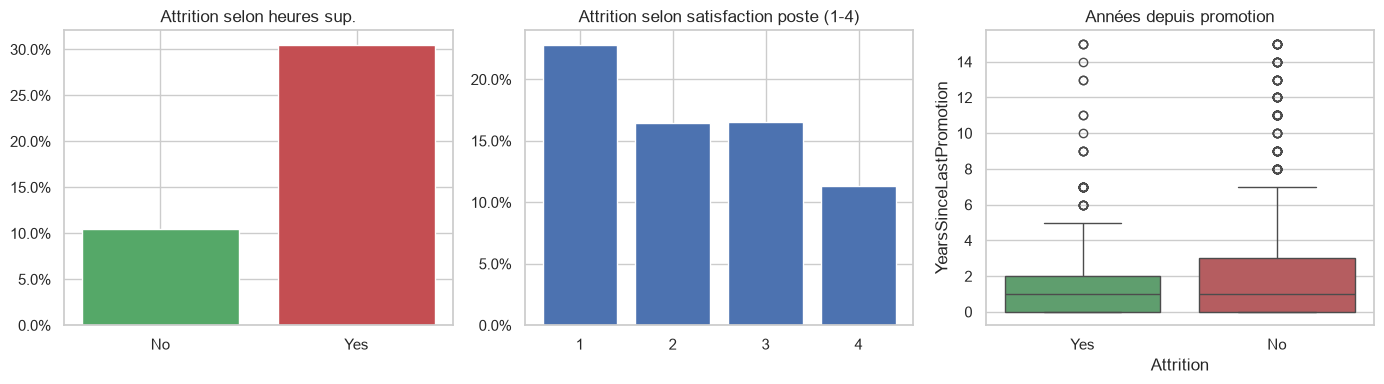

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

overtime_rate = df.groupby("OverTime")["Attrition_flag"].mean()
axes[0].bar(overtime_rate.index, overtime_rate.values, color=["#55A868", "#C44E52"])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title("Attrition selon heures sup.")

satisf_rate = df.groupby("JobSatisfaction")["Attrition_flag"].mean()
axes[1].bar(satisf_rate.index.astype(str), satisf_rate.values, color="#4C72B0")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title("Attrition selon satisfaction poste (1-4)")

sns.boxplot(data=df, x="Attrition", y="YearsSinceLastPromotion", hue="Attrition", ax=axes[2], palette=["#55A868", "#C44E52"], legend=False)
axes[2].set_title("Années depuis promotion")

plt.tight_layout()
plt.savefig("../reports/kpi_facteurs_attrition.png", dpi=150)
plt.show()

In [10]:
display(Markdown(
    "**Comment lire ce résultat.** Les trois p-values sont affichées dans le tableau au-dessus : "
    "en dessous de 0.05, l'association observée sur le graphique n'est pas qu'un effet du hasard "
    "d'échantillonnage. Ça ne veut pas dire que ces facteurs *causent* le départ, juste qu'ils y sont "
    "statistiquement associés, la nuance est volontaire, un backlog RH qui confondrait corrélation et "
    "causalité risquerait de faire agir l'entreprise sur le mauvais levier."
))

**Comment lire ce résultat.** Les trois p-values sont affichées dans le tableau au-dessus : en dessous de 0.05, l'association observée sur le graphique n'est pas qu'un effet du hasard d'échantillonnage. Ça ne veut pas dire que ces facteurs *causent* le départ, juste qu'ils y sont statistiquement associés, la nuance est volontaire, un backlog RH qui confondrait corrélation et causalité risquerait de faire agir l'entreprise sur le mauvais levier.

# 6. Équité salariale par genre, à niveau de poste équivalent (user story 3.1)

La user story précise explicitement de contrôler par niveau de poste, une moyenne brute non contrôlée serait trompeuse si la répartition hommes/femmes n'est pas la même à chaque niveau.

In [11]:
income_by_level_gender = (
    df.groupby(["JobLevel", "Gender"])["MonthlyIncome"]
    .median()
    .unstack()
)
income_by_level_gender["écart (F - M)"] = income_by_level_gender["Female"] - income_by_level_gender["Male"]
income_by_level_gender["écart en %"] = income_by_level_gender["écart (F - M)"] / income_by_level_gender["Male"]
income_by_level_gender

Gender,Female,Male,écart (F - M),écart en %
JobLevel,,,,
1,2659.0,2678.5,-19.5,-0.007280
2,5247.5,5383.5,-136.0,-0.025262
3,10052.0,9854.0,198.0,0.020093
4,16064.0,16328.0,-264.0,-0.016169
5,19071.5,19246.0,-174.5,-0.009067


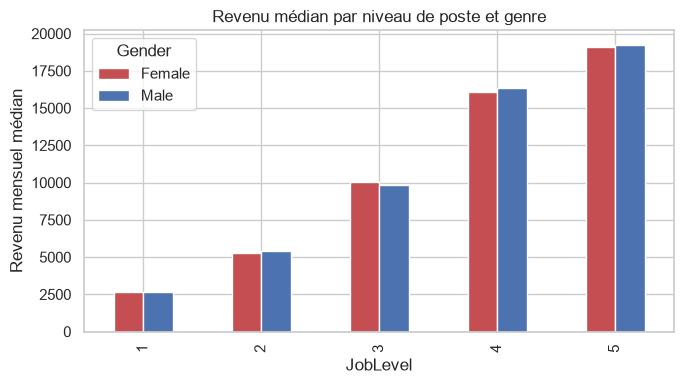

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
income_by_level_gender[["Female", "Male"]].plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Revenu mensuel médian")
ax.set_title("Revenu médian par niveau de poste et genre")
plt.tight_layout()
plt.savefig("../reports/kpi_equite_salariale.png", dpi=150)
plt.show()

In [13]:
max_gap = income_by_level_gender["écart en %"].abs().max()
level_max_gap = income_by_level_gender["écart en %"].abs().idxmax()

display(Markdown(
    f"**Comment lire ce résultat.** À niveau de poste équivalent, l'écart médian le plus marqué est au "
    f"niveau `{level_max_gap}` (`{income_by_level_gender.loc[level_max_gap, 'écart en %']:.1%}`). "
    f"Le contrôle par `JobLevel` change la lecture par rapport à une moyenne brute globale, c'est "
    f"précisément ce que demandait le critère d'acceptation de la user story."
))

**Comment lire ce résultat.** À niveau de poste équivalent, l'écart médian le plus marqué est au niveau `2` (`-2.5%`). Le contrôle par `JobLevel` change la lecture par rapport à une moyenne brute globale, c'est précisément ce que demandait le critère d'acceptation de la user story.

# 7. Bien-être par département (user story 3.2)

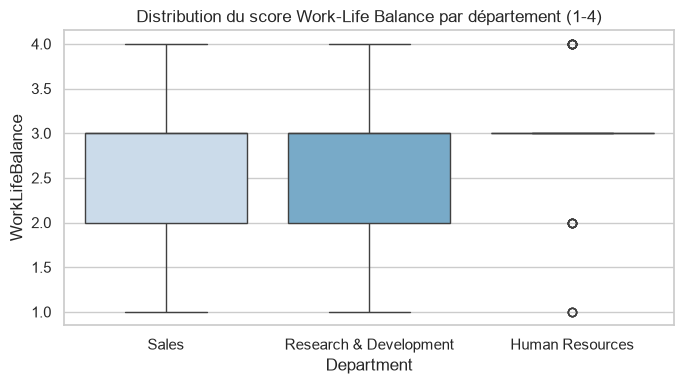

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="Department", y="WorkLifeBalance", hue="Department", ax=ax, palette="Blues", legend=False)
ax.set_title("Distribution du score Work-Life Balance par département (1-4)")
plt.tight_layout()
plt.savefig("../reports/kpi_worklife_balance.png", dpi=150)
plt.show()

# 8. Synthèse : ce que ce notebook montre, et ses limites

Ce que le backlog demandait est livré : un catalogue de données audité avant tout calcul, un requêtage SQL explicite pour les KPIs d'attrition (transposable à Snowflake), un taux d'attrition ventilé et non un chiffre unique masquant les effectifs, trois facteurs associés à l'attrition testés statistiquement plutôt qu'estimés à l'œil, un écart salarial contrôlé par niveau de poste plutôt qu'une moyenne brute, et un indicateur de bien-être par département. Un guide utilisateur autonome (`USER_GUIDE.md`) accompagne ce notebook pour la lecture du dashboard qui en découlerait.

**Limites à ne pas cacher.** Le jeu de données est un jeu public à but pédagogique (IBM), pas une extraction d'un vrai SI RH : les corrélations trouvées ici illustrent la méthode, elles ne constituent pas un diagnostic RH réel. Le requêtage est fait en DuckDB, pas littéralement sur Snowflake, faute d'accès à cet outil en dehors d'un contexte d'entreprise, mais le SQL écrit est transposable directement. La partie "animation de communauté / co-design" et les échanges avec des développeurs ou des équipes métier en direct (`BACKLOG.md`, note de transparence) n'ont pas été simulés par honnêteté, ce projet montre la construction technique et la méthode produit, pas une preuve d'expérience en facilitation d'équipe ou en coordination de projet réelle.

**Ce qui viendrait ensuite** dans un vrai contexte : brancher ce pipeline sur une source de données rafraîchie automatiquement plutôt qu'un CSV statique, exécuter les requêtes de la section 3 sur un entrepôt Snowflake réel, et transformer les visualisations matplotlib en dashboard Power BI interactif tel que décrit dans le backlog, ce notebook fournit les KPIs et leur définition, prêts à être repris dans l'outil de restitution final.